# Phase 3: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) helps us understand patterns, trends, and relationships in the dataset through summary statistics and visualizations.

### Business Questions

- What is the total sales revenue?
- What is the total profit?
- Which category generates the highest sales?
- Which region performs the best?
- Which products contribute the most revenue?
- How do discounts affect profit?

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset

df = pd.read_csv("../data/cleaned_superstore.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Dataset Preview

Display the first five rows to verify that the cleaned dataset has been loaded correctly.

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Calculate Total Sales

In [4]:
total_sales = df["Sales"].sum()

print("Total Sales: ₹", round(total_sales, 2))

Total Sales: ₹ 2326534.35


## Calculate Total Profit

In [5]:
total_profit = df["Profit"].sum()

print("Total Profit: ₹", round(total_profit, 2))

Total Profit: ₹ 292296.81


## Total Orders

In [6]:
total_orders = df["Order ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 5111


## Sales by Category

This chart shows the total sales generated by each product category.

### Business Question
Which product category contributes the highest sales?

In [7]:
# Calculate total sales by category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

## Visualizing Sales by Category

A bar chart helps compare sales across different product categories.

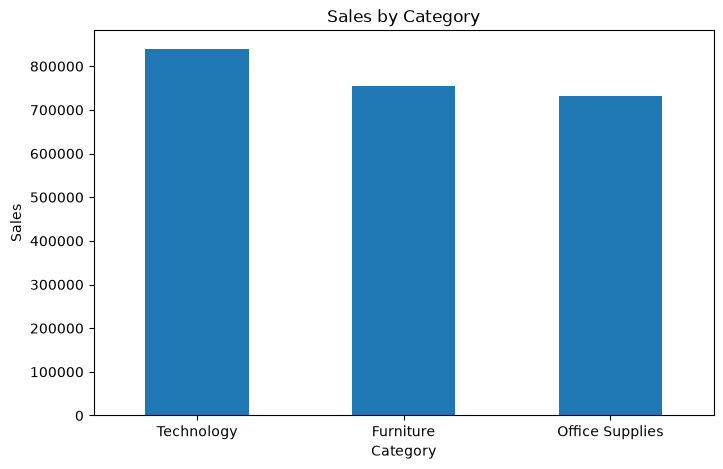

In [8]:
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

## Sales by Region

This analysis helps identify which geographical region generates the highest revenue.

In [9]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

## Visualizing Sales by Region

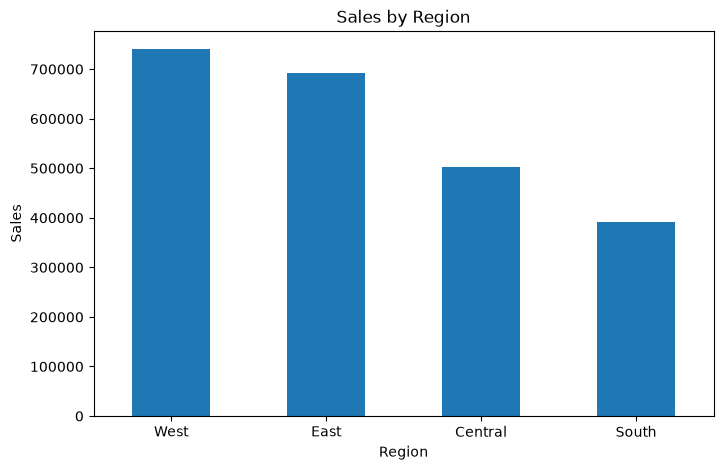

In [10]:
region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Top 10 Customers by Sales

Identifying high-value customers helps businesses improve customer retention and targeted marketing.

In [11]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

## Visualizing Top Customers

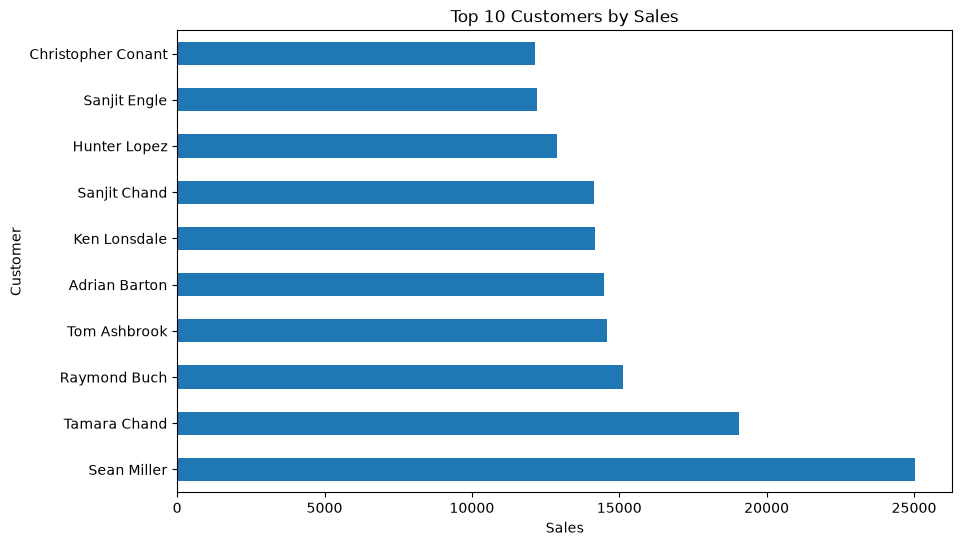

In [12]:
top_customers.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

## Monthly Sales Trend

This visualization shows how sales changed over time.

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.head()

Order Date
2023-01    14518.055
2023-02     4519.892
2023-03    56933.909
2023-04    28295.345
2023-05    26319.767
Name: Sales, dtype: float64

## Visualizing Monthly Sales Trend

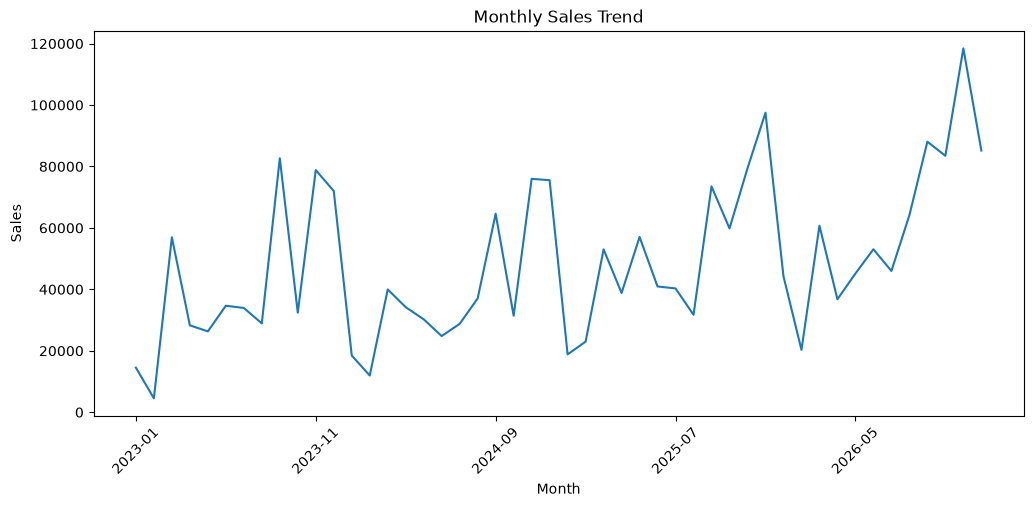

In [14]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()